In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/yellow_tripdata_2022-05.csv")

import matplotlib.pyplot as plt

/tmp/ipykernel_1125/1789784744.py:3: DtypeWarning: Columns (6: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/yellow_tripdata_2022-05.csv")


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3588295 entries, 0 to 3588294
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     str    
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  airport_fee            float64
dtypes: float64(12), int64(4), str(3)
memory usage: 701.8 MB


### Observaciones iniciales

- El dataset contiene 3,588,295 registros y 19 columnas.
- `tpep_pickup_datetime` y `tpep_dropoff_datetime` fueron cargadas como `str`, por lo que será necesario evaluar su conversión a tipo datetime antes de realizar análisis temporales.

In [3]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          129524
trip_distance                 0
RatecodeID               129524
store_and_fwd_flag       129524
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     129524
airport_fee              129524
dtype: int64

In [4]:
columns_with_nulls = [
    "passenger_count",
    "RatecodeID",
    "store_and_fwd_flag",
    "congestion_surcharge",
    "airport_fee"
]

df[columns_with_nulls].isna().all(axis=1).sum()

np.int64(129524)

### Valores faltantes

Se identificaron 129,524 registros con valores faltantes. Los valores nulos aparecen simultáneamente en `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge` y `airport_fee`.

Este patrón sugiere que los valores faltantes podrían tener un origen común, por lo que se analizarán estos registros antes de definir cualquier estrategia de limpieza o imputación.

In [5]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36.000000,2022-05-01 00:19:18.000000,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44.000000,2022-05-01 00:41:33.000000,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00.000000,2022-05-01 01:14:22.000000,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18.000000,2022-05-01 01:28:02.000000,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26.000000,2022-05-01 00:37:49.000000,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


# Se observa al menos un registro con trip_distance = 0 y fare_amount = 41.2. Se deberá verificar posteriormente la frecuencia y características de los viajes con distancia cero.

In [6]:
df.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,3.588295e+06,3.458771e+06,3.588295e+06,3.458771e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.588295e+06,3.458771e+06,3.458771e+06
mean,1.713103e+00,1.393923e+00,6.856861e+00,1.365674e+00,1.645738e+02,1.625517e+02,1.183209e+00,1.516813e+01,1.020728e+00,4.891096e-01,2.824744e+00,5.827756e-01,2.964299e-01,2.207840e+01,2.282808e+00,1.008364e-01
std,4.888093e-01,9.555489e-01,6.908488e+02,5.239789e+00,6.562813e+01,7.027926e+01,5.075988e-01,1.489484e+01,1.256724e+00,9.008878e-02,3.368739e+00,2.173699e+00,4.576907e-02,1.848683e+01,7.452415e-01,3.434480e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-1.311500e+03,-4.500000e+00,-5.000000e-01,-1.457000e+02,-5.075000e+01,-3.000000e-01,-1.314800e+03,-2.500000e+00,-1.250000e+00
25%,1.000000e+00,1.000000e+00,1.150000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,7.000000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,3.000000e-01,1.235000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,1.000000e+00,1.960000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.050000e+01,5.000000e-01,5.000000e-01,2.160000e+00,0.000000e+00,3.000000e-01,1.630000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,1.000000e+00,3.730000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.700000e+01,2.500000e+00,5.000000e-01,3.460000e+00,0.000000e+00,3.000000e-01,2.376000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,9.000000e+00,3.571927e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,6.966500e+03,8.800000e+00,3.300000e+00,6.650000e+02,8.137500e+02,3.000000e-01,6.970800e+03,2.750000e+00,1.250000e+00


- `fare_amount` presenta valores negativos, con un mínimo de -1311.50.  Antes de considerarlos datos erróneos, se debe validar si existen operaciones o reglas de negocio que puedan generar tarifas negativas.

- Se observan valores negativos en varias variables monetarias (`fare_amount`,
  `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `total_amount`,
  `congestion_surcharge` y `airport_fee`). Se debe investigar si corresponden
  a operaciones válidas del negocio (por ejemplo, ajustes o reversos) o a
  anomalías en los datos.

- `passenger_count` presenta valores entre 0 y 9. Los valores extremos,
  especialmente 0 y 9 pasajeros, requieren validación para determinar si
  corresponden a situaciones válidas del negocio o a anomalías de registro.

In [7]:
df["passenger_count"].value_counts(dropna=False)

passenger_count
1.0    2549880
2.0     539027
3.0     136997
NaN     129524
0.0      73587
5.0      61209
4.0      56092
6.0      41948
7.0         15
8.0         14
9.0          2
Name: count, dtype: int64

- `passenger_count` contiene únicamente valores enteros entre 0 y 9, además de
  valores faltantes. Se identificaron 73,587 registros con 0 pasajeros y únicamente
  31 registros con 7, 8 o 9 pasajeros. Estos valores requieren validación antes de
  decidir su tratamiento.

In [8]:
df["RatecodeID"].value_counts(dropna=False)

RatecodeID
1.0     3256985
2.0      147239
NaN      129524
5.0       28382
3.0       11636
99.0       9864
4.0        4626
6.0          39
Name: count, dtype: int64

- `RatecodeID` representa el régimen tarifario aplicado al viaje y, por su significado
  de negocio, puede estar directamente relacionado con `fare_amount`.
  Antes de utilizarlo como feature se debe evaluar si estos regímenes deben ser
  tratados como reglas de negocio y si pueden determinarse antes de iniciar el viaje.

In [9]:
df.duplicated().sum()

np.int64(0)

- No se identificaron registros duplicados en el dataset.

In [10]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

df[["tpep_pickup_datetime", "tpep_dropoff_datetime"]].dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
dtype: object

In [11]:
print("Pickup mínimo:", df["tpep_pickup_datetime"].min())
print("Pickup máximo:", df["tpep_pickup_datetime"].max())

print("Dropoff mínimo:", df["tpep_dropoff_datetime"].min())
print("Dropoff máximo:", df["tpep_dropoff_datetime"].max())

Pickup mínimo: 2003-01-01 00:06:06
Pickup máximo: 2022-06-01 23:55:30
Dropoff mínimo: 2003-01-01 00:31:38
Dropoff máximo: 2022-06-02 00:03:51


In [12]:
may_pickups = (
    (df["tpep_pickup_datetime"].dt.year == 2022) &
    (df["tpep_pickup_datetime"].dt.month == 5)
)

#may_pickups.sum()

(~may_pickups).sum()

np.int64(143)

- Se identificaron 143 registros cuya fecha de recogida no corresponde a mayo de 2022.
  Aunque representan una proporción muy pequeña del dataset, deben revisarse antes
  de definir su tratamiento durante la limpieza.

In [13]:
df["trip_duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration"].describe()

count    3.588295e+06
mean     1.821760e+01
std      5.156663e+01
min     -1.408333e+01
25%      7.666667e+00
50%      1.270000e+01
75%      2.061667e+01
max      6.823550e+03
Name: trip_duration, dtype: float64

- `trip_duration` presenta valores anómalos que requieren investigación. Se
  identifican duraciones negativas (mínimo de -14.08 minutos), que no son
  físicamente válidas, y duraciones extremadamente altas (máximo de 6,823.55
  minutos, aproximadamente 4.74 días). El 75% de los viajes presenta una
  duración igual o inferior a 20.62 minutos.

In [14]:
invalid_duration = df["trip_duration"] <= 0
invalid_duration.sum()

np.int64(3030)

- Se identificaron 3,030 registros con `trip_duration <= 0`, equivalentes
  aproximadamente al 0.084% del dataset. Estas duraciones no representan
  viajes con una duración física válida y deberán ser consideradas durante
  la etapa de limpieza.

In [15]:
invalid_distance = df["trip_distance"] <= 0
invalid_distance.sum()




np.int64(46438)

- Se identificaron 46,438 registros con `trip_distance <= 0`, aproximadamente
  el 1.29% del dataset. Estos registros requieren revisión antes de definir
  su tratamiento durante la limpieza.

#Ya inicié mi EDA sobre el dataset completo de mayo, con 3.588.295 registros y 19 variables. Revisé estructura, tipos de datos, valores faltantes y duplicados. Encontré un patrón de 129.524 registros que comparten valores nulos en cinco variables y no encontré filas duplicadas. También revisé variables categóricas como passenger_count y RatecodeID, y detecté anomalías que requieren investigación, incluyendo 143 registros con pickup fuera de mayo, 3.030 viajes con duración menor o igual a cero y 46.438 con distancia menor o igual a cero. Ya generé además trip_duration a partir de pickup y dropoff y encontré valores extremos que deberán revisarse durante la limpieza. Todavía estoy continuando el análisis antes de tomar decisiones de eliminación o imputación.

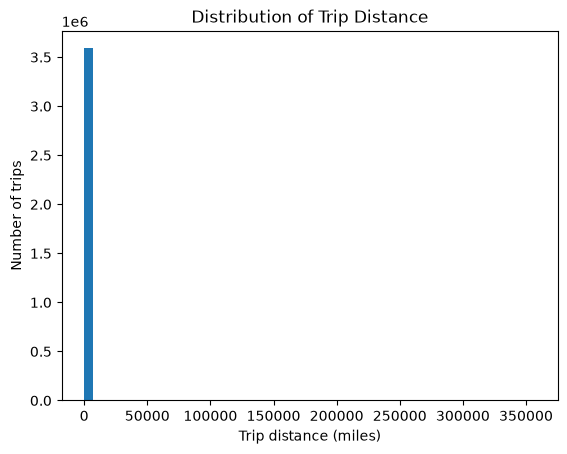

In [16]:
plt.hist(df["trip_distance"], bins=50)
plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.title("Distribution of Trip Distance")
plt.show()

In [17]:
df["trip_distance"].quantile(0.99)

np.float64(20.3)

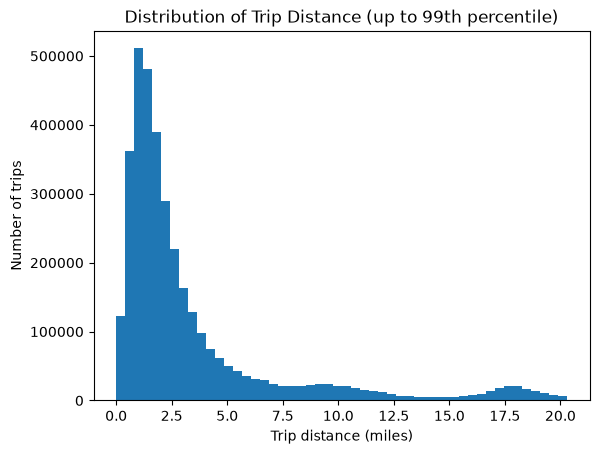

In [18]:
plt.hist(df["trip_distance"], bins=50, range=(0, 20.3))
plt.xlabel("Trip distance (miles)")
plt.ylabel("Number of trips")
plt.title("Distribution of Trip Distance (up to 99th percentile)")
plt.show()

Distribución de trip_distance: La variable presenta una distribución asimétrica con sesgo hacia la derecha. La mayor concentración de viajes corresponde a distancias cortas, mientras que una menor proporción se extiende hacia distancias mayores. Para facilitar su visualización, se utilizó el percentil 99 (20.3 millas) como límite del histograma, sin modificar los registros originales. Dada esta distribución, se utilizará IQR como método inicial para identificar posibles valores atípicos, que posteriormente serán evaluados mediante criterios del dominio.

In [19]:
q1 = df["trip_distance"].quantile(0.25)
q3 = df["trip_distance"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 1.15
Q3: 3.73
IQR: 2.58
Lower bound: -2.72
Upper bound: 7.6


In [21]:
distance_outliers = (
    (df["trip_distance"] < lower_bound) |
    (df["trip_distance"] > upper_bound)
)

distance_outliers.sum()

np.int64(455943)

In [22]:
(distance_outliers.sum() / len(df)) * 100

np.float64(12.70639677061111)

Outliers de trip_distance: mediante el método IQR se identificaron 455.943 registros (12,71 %) fuera de los límites estadísticos calculados (< -2.72 o > 7.60 millas). Estos registros se consideran valores atípicos candidatos y no serán eliminados automáticamente, ya que distancias superiores a 7.60 millas pueden corresponder a viajes válidos. Su tratamiento deberá complementarse con criterios de dominio para distinguir viajes plausibles de valores potencialmente erróneos.

In [23]:
df.loc[distance_outliers, "trip_distance"].describe()

count    455943.000000
mean         39.265399
std        1937.767730
min           7.610000
25%           9.680000
50%          12.600000
75%          17.800000
max      357192.650000
Name: trip_distance, dtype: float64

In [24]:
df.loc[distance_outliers, "trip_distance"].quantile(
    [0.90, 0.95, 0.99, 0.999]
)

0.900    19.7100
0.950    21.2500
0.990    28.3400
0.999    54.0529
Name: trip_distance, dtype: float64

In [25]:
extreme_distance_threshold = df.loc[distance_outliers, "trip_distance"].quantile(0.999)

extreme_distance = df["trip_distance"] > extreme_distance_threshold

extreme_distance.sum()

np.int64(456)

In [26]:
df.loc[extreme_distance, "trip_distance"]

4869           54.30
13914         128.01
16194          64.89
17686         111.04
18575          80.13
             ...    
3584552    128742.58
3585670    131884.34
3585679    109774.82
3588029     45022.68
3588052    101825.47
Name: trip_distance, Length: 456, dtype: float64

In [28]:
df.loc[extreme_distance, "trip_distance"].sort_values(ascending=False)

3528934    357192.65
3543875    344408.48
3469281    333632.96
3482491    281179.94
3543592    275692.34
             ...    
2564212        54.20
2957305        54.19
1801354        54.18
681696         54.17
28192          54.10
Name: trip_distance, Length: 456, dtype: float64

In [31]:
df.loc[extreme_distance, ["trip_distance", "fare_amount", "trip_duration"]].sort_values(
    by="trip_distance",
    ascending=False
)

,trip_distance,fare_amount,trip_duration
3528934,357192.65,12.46,12.000000
3543875,344408.48,63.12,80.000000
3469281,333632.96,16.51,22.000000
3482491,281179.94,34.76,19.000000
3543592,275692.34,8.89,10.000000
...,...,...,...
2564212,54.20,239.00,137.900000
2957305,54.19,240.00,64.183333
1801354,54.18,265.00,62.966667
681696,54.17,220.00,88.016667


# IQR para Fare_Amount

In [33]:
fare_p99 = df["fare_amount"].quantile(0.99)
fare_p99

np.float64(63.0)

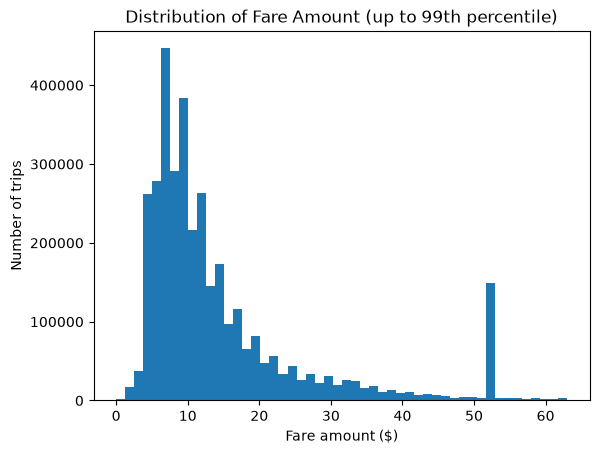

In [34]:
plt.hist(df["fare_amount"], bins=50, range=(0, fare_p99))
plt.xlabel("Fare amount ($)")
plt.ylabel("Number of trips")
plt.title("Distribution of Fare Amount (up to 99th percentile)")
plt.show()

In [35]:
fare_q1 = df["fare_amount"].quantile(0.25)
fare_q3 = df["fare_amount"].quantile(0.75)
fare_iqr = fare_q3 - fare_q1
fare_lower_bound = fare_q1 - 1.5 * fare_iqr
fare_upper_bound = fare_q3 + 1.5 * fare_iqr

print("Fare Q1:", fare_q1)
print("Fare Q3:", fare_q3)
print("Fare IQR:", fare_iqr)
print("Fare Lower bound:", fare_lower_bound)
print("Fare Upper bound:", fare_upper_bound)

Fare Q1: 7.0
Fare Q3: 17.0
Fare IQR: 10.0
Fare Lower bound: -8.0
Fare Upper bound: 32.0


In [36]:
fare_outliers = (
    (df["fare_amount"] < fare_lower_bound) |
    (df["fare_amount"] > fare_upper_bound)
)

fare_outliers.sum()

np.int64(371211)

In [37]:
(fare_outliers.sum() / len(df)) * 100

np.float64(10.34505245527472)

In [38]:
df.loc[fare_outliers, "fare_amount"].sort_values(ascending=True)

2536784   -1311.5
1779648    -900.0
2345183    -576.0
1595148    -535.0
1636750    -500.0
            ...  
3248725     855.0
1779649     900.0
1788460     900.0
2536785    1311.5
3414224    6966.5
Name: fare_amount, Length: 371211, dtype: float64

- fare_amount <= 0 → proponer exclusión del dataset de entrenamiento del modelo de tarifa, porque no representa una tarifa positiva que queramos predecir. Posteriormente se debe validar el significado de estos registros en el dominio antes de establecer la regla definitiva.

- fare_amount > 32 → outlier estadístico según IQR; no implica exclusión automática, porque una tarifa superior a $32 puede ser perfectamente válida.

# IQR Trip_Duration

In [40]:
duration_p99 = df["trip_duration"].quantile(0.99)
duration_p99

np.float64(71.45)

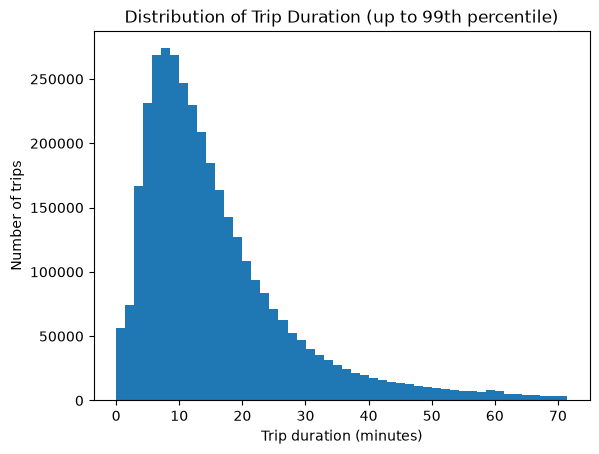

In [41]:
plt.hist(df["trip_duration"], bins=50, range=(0, duration_p99))
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Number of trips")
plt.title("Distribution of Trip Duration (up to 99th percentile)")
plt.show()

In [42]:
duration_q1 = df["trip_duration"].quantile(0.25)
duration_q3 = df["trip_duration"].quantile(0.75)
duration_iqr = duration_q3 - duration_q1

duration_lower_bound = duration_q1 - 1.5 * duration_iqr
duration_upper_bound = duration_q3 + 1.5 * duration_iqr

print(f"Lower bound: {duration_lower_bound}")
print(f"Upper bound: {duration_upper_bound}")

Lower bound: -11.75833333333333
Upper bound: 40.041666666666664


In [43]:
duration_outliers = (
    (df["trip_duration"] < duration_lower_bound) |
    (df["trip_duration"] > duration_upper_bound)
)

duration_outliers.sum()

np.int64(223768)

In [44]:
(duration_outliers.sum() / len(df)) * 100

np.float64(6.2360536132062725)

El análisis de outliers no debe basarse únicamente en criterios estadísticos. Para trip_duration, el método IQR identificó 223.768 registros (6,24 %) fuera del intervalo estadístico aproximado [-11,76; 40,04] minutos. Sin embargo, adicionalmente se identificaron 3.030 registros con duración menor o igual a cero, que resultan inválidos según la lógica del dominio aunque algunos no sean detectados como outliers por IQR.

| Variable | Candidatos IQR | % | Decisión preliminar |
|---|---:|---:|---|
| `trip_distance` | 455.943 | 12,71 % | No eliminar por IQR; investigar extremos y aplicar dominio |
| `fare_amount` | 371.211 | 10,35 % | No eliminar por IQR; `<= 0` candidato a exclusión **solo del modelo de tarifa** |
| `trip_duration` | 223.768 | 6,24 % | No eliminar por IQR; `<= 0` inválido para duración |